# Laboratorio COCO — Detección de objetos y segmentación de instancias con YOLO (Transfer Learning)

**Talento Altamente Especializado — Inteligencia Artificial 2026**
**COCYTEN-Nayarit**

**Instructor:** M.Sc. Mario Iván López Valdovinos
**Alumno:**  Agustin Jaime Navarro
**Fecha de asignación:** 24/07/2026

---

## Objetivo

Implementar y evaluar dos redes neuronales basadas en **YOLO** (Ultralytics) sobre un subconjunto del dataset **COCO**:

1. Un modelo de **detección de objetos** (bounding boxes).
2. Un modelo de **segmentación de instancias** (máscaras a nivel de píxel).

Ambos modelos se entrenan mediante **transfer learning**: partimos de pesos ya preentrenados en COCO completo y realizamos *fine-tuning* sobre nuestra propia partición del subconjunto (70% train / 15% val / 15% test), tal como se indicó en la sesión del 24/07/2026: *"quiero que hagan el respectivo entrenamiento, pero únicamente para el transfer learning... y quiero que hagan su respectiva partición y también quiero que hagan y reporten las métricas".*

Al final se reportan las métricas de detección y segmentación solicitadas, y se muestran ejemplos visuales: imagen original, anotación *ground-truth*, predicción de caja delimitadora, predicción de máscara y su *score* de confianza.

## Nota sobre el entorno de ejecución

Este notebook está optimizado para ejecutarse **en CPU, sin GPU/CUDA**, en un equipo con recursos moderados (ej. procesador AMD Ryzen 7 5825U, 8 GB RAM). Por eso:

- Usamos un **subconjunto de COCO** (`coco128` / `coco128-seg`, 128 imágenes reales de COCO train2017 con sus anotaciones) en lugar del dataset completo (~20+ GB), como el instructor autorizó explícitamente en la sesión ("pueden usar una versión más pequeña").
- Usamos los modelos **más ligeros** de la familia YOLOv8: `yolov8n.pt` (detección) y `yolov8n-seg.pt` (segmentación), variante *nano*.
- Reducimos el tamaño de imagen de entrenamiento (`imgsz=320`), el tamaño de lote (`batch=8`) y el número de *workers* para no saturar los 8 GB de RAM.
- Todos los parámetros están expuestos en variables al inicio del notebook — si tu equipo tiene más recursos, puedes subir `IMG_SIZE`, `BATCH_SIZE` y `EPOCHS` para mejorar las métricas.


## 1. Instalación de librerías

Instalamos:
- **`ultralytics`**: implementación oficial de YOLOv8, incluye entrenamiento, validación, inferencia y descarga automática de pesos/datasets.
- **`torch`**: viene como dependencia de `ultralytics` (se instala en su versión CPU si no hay CUDA disponible).
- **`matplotlib`**: para desplegar las imágenes con anotaciones y predicciones.
- **`opencv-python`**: manejo de imágenes y máscaras (redimensionado, dibujo de contornos).
- **`pandas`**: para tabular las métricas finales de forma ordenada.

> Si ya tienes estas librerías instaladas, esta celda no las reinstala (usa `-q` y pip detecta lo ya instalado).


In [1]:
%pip install -q ultralytics matplotlib opencv-python pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.4 MB/s eta 0:00:00


In [2]:
import os
import shutil
import random
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

from ultralytics import YOLO
from ultralytics.utils.downloads import safe_download

# -----------------------------------------------------------------------
# CONFIGURACIÓN GENERAL — ajusta aquí según el hardware disponible
# -----------------------------------------------------------------------
SEED        = 42                 # semilla para reproducibilidad de la partición
DEVICE      = "cpu"              # "cpu" porque no tenemos GPU/CUDA disponible
IMG_SIZE    = 320                # tamaño de imagen de entrenamiento (reducido para 8 GB RAM)
BATCH_SIZE  = 8                  # lote pequeño para no saturar la RAM
EPOCHS_DET  = 25                 # épocas para fine-tuning de detección
EPOCHS_SEG  = 25                 # épocas para fine-tuning de segmentación
WORKERS     = 2                  # hilos de carga de datos (Ryzen 7 5825U: 8 núcleos/16 hilos, dejamos margen de RAM)

SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.15
SPLIT_TEST  = 0.15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path.cwd()
print(f"Dispositivo de cómputo: {DEVICE}")
print(f"PyTorch ve CUDA disponible: {torch.cuda.is_available()}  (debe ser False en este equipo)")
print(f"Directorio de trabajo: {BASE_DIR}")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dispositivo de cómputo: cpu
PyTorch ve CUDA disponible: False  (debe ser False en este equipo)
Directorio de trabajo: /content


## 2. Descarga del dataset COCO (subconjunto)

Como se autorizó en la sesión de laboratorio, en lugar de descargar el dataset COCO completo (~118,000 imágenes de entrenamiento, más de 20 GB) usamos **`coco128`** y **`coco128-seg`**: subconjuntos oficiales de Ultralytics con **128 imágenes reales tomadas de COCO `train2017`**, ya con:

- Anotaciones de **bounding boxes** en formato YOLO (`coco128`).
- Anotaciones de **máscaras/polígonos de segmentación** en formato YOLO (`coco128-seg`).

Ambos usan las **80 categorías originales de COCO**. `safe_download` descarga y descomprime automáticamente si el subconjunto no existe todavía en `~/.config/Ultralytics` / `./datasets`.


In [3]:
DATASETS_DIR = BASE_DIR / "datasets"
DATASETS_DIR.mkdir(exist_ok=True)

def download_subset(name, url):
    target = DATASETS_DIR / name
    if target.exists():
        print(f"'{name}' ya existe, se omite la descarga.")
        return target
    print(f"Descargando subconjunto '{name}'...")
    safe_download(url=url, dir=DATASETS_DIR, unzip=True, retry=2)
    return target

coco128_dir     = download_subset("coco128",     "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip")
coco128seg_dir  = download_subset("coco128-seg", "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip")

print("Imágenes detección:   ", len(list((coco128_dir / "images" / "train2017").glob("*.jpg"))))
print("Imágenes segmentación:", len(list((coco128seg_dir / "images" / "train2017").glob("*.jpg"))))


Descargando subconjunto 'coco128'...
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 1.0Kfiles/s 0.3s
Descargando subconjunto 'coco128-seg'...
Unzipping /content/datasets/coco128-seg.zip to /content/datasets/coco128-seg...: 100% ━━━━━━━━━━━━ 263/263 501.1files/s 0.5s
Imágenes detección:    128
Imágenes segmentación: 128


## 3. Partición del dataset en 70% train / 15% val / 15% test

`coco128` viene con todas sus imágenes en una sola carpeta (`train2017`). Construimos **nuestra propia partición aleatoria** (semilla fija para reproducibilidad) y la organizamos en la estructura de carpetas que espera Ultralytics:

```
dataset_split/
├── images/{train,val,test}/*.jpg
└── labels/{train,val,test}/*.txt
```

La función `split_dataset`:
1. Lista todas las imágenes disponibles.
2. Las mezcla con una semilla fija (`SEED`) para que la partición sea reproducible.
3. Calcula los cortes según `SPLIT_TRAIN/VAL/TEST` (70/15/15).
4. Copia cada imagen **y su archivo de etiqueta correspondiente** (mismo nombre, extensión `.txt`) a la carpeta de su partición.

Se ejecuta una vez para el subconjunto de **detección** (`coco128`) y otra para el de **segmentación** (`coco128-seg`), ya que ambos tienen el mismo conjunto de imágenes pero etiquetas distintas (cajas vs. polígonos).


In [4]:
def split_dataset(source_dir: Path, dest_dir: Path,
                   train_ratio=SPLIT_TRAIN, val_ratio=SPLIT_VAL, test_ratio=SPLIT_TEST):
    """Divide un dataset en formato YOLO (images/ + labels/) en train/val/test.

    Parameters
    ----------
    source_dir : carpeta que contiene images/train2017 y labels/train2017
    dest_dir   : carpeta destino donde se crea la estructura partida
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Los splits deben sumar 1.0"

    images = sorted((source_dir / "images" / "train2017").glob("*.jpg"))
    random.Random(SEED).shuffle(images)

    n = len(images)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    # el resto (redondeo incluido) se va a test para no perder imágenes
    splits = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:],
    }

    for split_name, split_images in splits.items():
        img_out = dest_dir / "images" / split_name
        lbl_out = dest_dir / "labels" / split_name
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path in split_images:
            label_path = source_dir / "labels" / "train2017" / (img_path.stem + ".txt")
            shutil.copy(img_path, img_out / img_path.name)
            if label_path.exists():
                shutil.copy(label_path, lbl_out / label_path.name)

    print(f"{dest_dir.name}: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}  (total={n})")
    return {k: len(v) for k, v in splits.items()}


DET_SPLIT_DIR = BASE_DIR / "dataset_split_det"
SEG_SPLIT_DIR = BASE_DIR / "dataset_split_seg"

det_counts = split_dataset(coco128_dir,    DET_SPLIT_DIR)
seg_counts = split_dataset(coco128seg_dir, SEG_SPLIT_DIR)


dataset_split_det: train=89  val=19  test=20  (total=128)
dataset_split_seg: train=89  val=19  test=20  (total=128)


## 4. Preparación de las anotaciones

### 4.1 Formato de anotación para detección (bounding boxes)

Cada imagen tiene un archivo `.txt` con **una línea por objeto**:

```
<clase> <x_centro> <y_centro> <ancho> <alto>
```

Todos los valores de posición están **normalizados entre 0 y 1** respecto al ancho/alto de la imagen (formato YOLO estándar).

### 4.2 Formato de anotación para segmentación (máscaras)

Es igual, pero en vez de 4 valores de caja, cada línea contiene el **polígono completo** del contorno del objeto:

```
<clase> x1 y1 x2 y2 x3 y3 ... xn yn
```

También normalizado entre 0 y 1. Ultralytics reconstruye la máscara rellenando el polígono.

### 4.3 Archivos `data.yaml`

Ultralytics necesita un archivo `.yaml` que le indique dónde están las carpetas `train/val/test` y los nombres de las 80 clases de COCO. Los generamos automáticamente a partir de los `data.yaml` originales de `coco128` / `coco128-seg` (mismas 80 clases), apuntando a nuestra propia partición.


In [5]:
import yaml
import ultralytics

# Los archivos coco128.yaml / coco128-seg.yaml (con los nombres de las 80 clases)
# vienen incluidos dentro del propio paquete "ultralytics", no dentro del .zip del subconjunto.
ULTRALYTICS_CFG_DIR = Path(ultralytics.__file__).parent / "cfg" / "datasets"

def load_class_names(yaml_filename: str):
    yaml_path = ULTRALYTICS_CFG_DIR / yaml_filename
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    return data["names"]

det_names = load_class_names("coco128.yaml")
seg_names = load_class_names("coco128-seg.yaml")

def write_data_yaml(dest_dir: Path, names, out_path: Path):
    data = {
        "path":  str(dest_dir.resolve()),
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "names": names,
    }
    with open(out_path, "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    return out_path

det_yaml = write_data_yaml(DET_SPLIT_DIR, det_names, BASE_DIR / "det_data.yaml")
seg_yaml = write_data_yaml(SEG_SPLIT_DIR, seg_names, BASE_DIR / "seg_data.yaml")

print(f"{len(det_names)} clases de COCO cargadas")
print("Ejemplo de anotación de detección (bounding box):")
example_label = next((DET_SPLIT_DIR / "labels" / "train").glob("*.txt"))
print(f"  archivo: {example_label.name}")
print("  " + open(example_label).readline().strip())

print("\nEjemplo de anotación de segmentación (polígono):")
example_seg_label = next((SEG_SPLIT_DIR / "labels" / "train").glob("*.txt"))
print(f"  archivo: {example_seg_label.name}")
line = open(example_seg_label).readline().strip().split()
print(f"  clase={line[0]}  puntos_del_poligono={len(line[1:]) // 2}")


80 clases de COCO cargadas
Ejemplo de anotación de detección (bounding box):
  archivo: 000000000560.txt
  58 0.178391 0.504327 0.120261 0.199808

Ejemplo de anotación de segmentación (polígono):
  archivo: 000000000560.txt
  clase=58  puntos_del_poligono=44


## 5. Carga del modelo YOLO preentrenado (detección)

Cargamos **`yolov8n.pt`**, la variante *nano* de YOLOv8, preentrenada sobre el dataset COCO completo (80 clases). Es la versión más ligera de la familia YOLOv8 (~3.2M parámetros), ideal para CPU con RAM limitada.

Al cargar estos pesos, el modelo ya "sabe" reconocer las 80 categorías de COCO — es el punto de partida para el **transfer learning**: en vez de aprender desde cero, ajustamos (*fine-tuning*) estos pesos usando únicamente nuestra partición de entrenamiento.


In [6]:
model_det = YOLO("yolov8n.pt")   # descarga automática de los pesos preentrenados si no existen localmente
print(model_det.model)


DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

## 6. Entrenamiento (transfer learning) del modelo de detección

`model.train(...)` realiza el *fine-tuning*: parte de los pesos preentrenados (`yolov8n.pt`) y continúa el entrenamiento sobre nuestro `train`, validando cada época contra nuestro `val`. Parámetros usados:

| Parámetro | Valor | Motivo |
|---|---|---|
| `data`    | `det_data.yaml` | apunta a nuestra partición 70/15/15 |
| `epochs`  | `EPOCHS_DET` | pocas épocas: dataset pequeño + fine-tuning, no entrenamiento desde cero |
| `imgsz`   | `IMG_SIZE` (320) | reduce uso de RAM/CPU vs. el default de 640 |
| `batch`   | `BATCH_SIZE` (8) | lote pequeño para no saturar 8 GB de RAM |
| `device`  | `"cpu"` | no hay GPU/CUDA disponible |
| `patience`| 10 | *early stopping* si no mejora, para no desperdiciar tiempo de CPU |


In [7]:
train_results_det = model_det.train(
    data=str(det_yaml),
    epochs=EPOCHS_DET,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    patience=10,
    seed=SEED,
    project="runs_lab",
    name="deteccion_transfer_learning",
    exist_ok=True,
    plots=True,
)


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/det_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deteccion_transfer_learning, nbs=64, 

## 7. Carga del modelo YOLO preentrenado (segmentación)

Igual que en detección, pero con **`yolov8n-seg.pt`**: la misma arquitectura *nano*, con una cabeza adicional (*mask head*) que predice un prototipo de máscara por cada detección.


In [8]:
model_seg = YOLO("yolov8n-seg.pt")
print(model_seg.model)


SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
 

## 8. Entrenamiento (transfer learning) del modelo de segmentación

Mismo procedimiento y misma partición (70/15/15), esta vez sobre el subconjunto con anotaciones de máscara (`seg_data.yaml`).


In [ ]:
train_results_seg = model_seg.train(
    data=str(seg_yaml),
    epochs=EPOCHS_SEG,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    patience=10,
    seed=SEED,
    project="runs_lab",
    name="segmentacion_transfer_learning",
    exist_ok=True,
    plots=True,
)


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/seg_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=segmentacion_transfer_learning, n

## 9. Evaluación del modelo de detección sobre el conjunto de *test*

Evaluamos con `model.val(split="test")`, que corre inferencia sobre el 15% de imágenes que el modelo **nunca vio** durante entrenamiento ni validación, y calcula automáticamente:

- **Precision** y **Recall** (promediados sobre todas las clases, en el umbral de confianza óptimo).
- **F1-score** = $\dfrac{2 \cdot Precision \cdot Recall}{Precision + Recall}$ (no lo entrega Ultralytics directamente, lo calculamos nosotros).
- **mAP@0.50**: *mean Average Precision* usando un único umbral de IoU = 0.50 para considerar una detección correcta.
- **mAP@0.50:0.95**: promedio del AP evaluado en 10 umbrales de IoU (0.50, 0.55, ..., 0.95) — métrica estándar de COCO, más estricta.


In [ ]:
metrics_det = model_det.val(data=str(det_yaml), split="test", device=DEVICE)

precision_det = float(metrics_det.box.mp)     # mean precision
recall_det    = float(metrics_det.box.mr)     # mean recall
f1_det        = 2 * precision_det * recall_det / (precision_det + recall_det + 1e-9)
map50_det     = float(metrics_det.box.map50)
map5095_det   = float(metrics_det.box.map)

det_metrics_table = pd.DataFrame({
    "Métrica": ["Precision", "Recall", "F1-score", "mAP@0.50", "mAP@0.50:0.95"],
    "Valor":   [precision_det, recall_det, f1_det, map50_det, map5095_det],
})
det_metrics_table


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1035.0±276.8 MB/s, size: 52.6 KB)
val: Scanning /content/dataset_split_det/labels/test... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 1.9Kit/s 0.0s
val: New cache created: /content/dataset_split_det/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         20        106      0.519      0.621      0.702       0.56
                person          9         27      0.478      0.556      0.605      0.447
               bicycle          1          2          1          0    0.00589     0.0053
                   car          2          4      0.339       0.25      0.245      0.221
            motorcycle          1          2      0.254          1    

,Métrica,Valor
0,Precision,0.518631
1,Recall,0.620966
2,F1-score,0.565203
3,mAP@0.50,0.702054
4,mAP@0.50:0.95,0.560027


## 10. Evaluación del modelo de segmentación sobre el conjunto de *test*

Para el modelo de segmentación, `metrics.seg` contiene las métricas equivalentes pero calculadas sobre la **superposición de máscaras** (en vez de cajas): Mask Precision, Mask Recall, Mask mAP@0.50 y Mask mAP@0.50:0.95.


In [ ]:
metrics_seg = model_seg.val(data=str(seg_yaml), split="test", device=DEVICE)

mask_precision = float(metrics_seg.seg.mp)
mask_recall    = float(metrics_seg.seg.mr)
mask_map50     = float(metrics_seg.seg.map50)
mask_map5095   = float(metrics_seg.seg.map)

seg_metrics_table = pd.DataFrame({
    "Métrica": ["Mask Precision", "Mask Recall", "Mask mAP@0.50", "Mask mAP@0.50:0.95"],
    "Valor":   [mask_precision, mask_recall, mask_map50, mask_map5095],
})
seg_metrics_table


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-seg summary (fused): 86 layers, 3,404,320 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1448.8±455.5 MB/s, size: 66.1 KB)
val: Scanning /content/dataset_split_seg/labels/test... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 1.2Kit/s 0.0s
val: New cache created: /content/dataset_split_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.7s
                   all         20        106       0.74      0.618      0.651      0.523       0.81      0.513       0.62      0.413
                person          9         27      0.872      0.556      0.617      0.432          1      0.553      0.616      0.338
               bicycle          1          2          1          0      0.045     0.0242          1          

,Métrica,Valor
0,Mask Precision,0.809830
1,Mask Recall,0.513494
2,Mask mAP@0.50,0.619778
3,Mask mAP@0.50:0.95,0.412972


## 11. Intersección sobre Unión (IoU) y Coeficiente de Dice

`metrics.seg` ya reporta mAP de máscara (que internamente usa IoU), pero el laboratorio pide reportar **IoU y Dice de forma explícita**. Los calculamos manualmente comparando, píxel a píxel, la máscara predicha contra la máscara *ground-truth*, para las imágenes del conjunto de test.

### Fórmulas

Dadas una máscara predicha $A$ y una máscara real (*ground truth*) $B$, ambas como conjuntos de píxeles activados:

$$IoU(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

$$Dice(A, B) = \frac{2 \, |A \cap B|}{|A| + |B|}$$

- **IoU** penaliza tanto los falsos positivos como los falsos negativos por igual, dividiendo el área de solapamiento entre el área total cubierta por ambas máscaras.
- **Dice** (equivalente al F1-score aplicado a áreas) le da el doble de peso al área de intersección, por eso normalmente da un valor un poco más alto que el IoU para la misma pareja de máscaras. Se relacionan mediante $Dice = \dfrac{2\,IoU}{1+IoU}$.

Ambas van de 0 (sin solapamiento) a 1 (máscaras idénticas).


In [ ]:
def compute_iou(mask_pred: np.ndarray, mask_gt: np.ndarray) -> float:
    """IoU entre dos máscaras binarias (mismo tamaño, valores 0/1 o booleanos)."""
    mask_pred = mask_pred.astype(bool)
    mask_gt = mask_gt.astype(bool)
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    union = np.logical_or(mask_pred, mask_gt).sum()
    if union == 0:
        return 0.0
    return intersection / union


def compute_dice(mask_pred: np.ndarray, mask_gt: np.ndarray) -> float:
    """Coeficiente de Dice entre dos máscaras binarias."""
    mask_pred = mask_pred.astype(bool)
    mask_gt = mask_gt.astype(bool)
    intersection = np.logical_and(mask_pred, mask_gt).sum()
    denom = mask_pred.sum() + mask_gt.sum()
    if denom == 0:
        return 0.0
    return (2.0 * intersection) / denom


def polygon_label_to_mask(label_line: str, img_h: int, img_w: int) -> np.ndarray:
    """Convierte una línea de anotación de segmentación (clase + polígono normalizado)
    en una máscara binaria del tamaño de la imagen."""
    parts = label_line.strip().split()
    coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
    coords[:, 0] *= img_w
    coords[:, 1] *= img_h
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(mask, [coords.astype(np.int32)], 1)
    return mask


# Calculamos IoU y Dice promedio sobre las imágenes del test set de segmentación
test_images_seg = sorted((SEG_SPLIT_DIR / "images" / "test").glob("*.jpg"))

iou_scores, dice_scores = [], []

for img_path in test_images_seg:
    label_path = SEG_SPLIT_DIR / "labels" / "test" / (img_path.stem + ".txt")
    if not label_path.exists():
        continue

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    # Máscara ground-truth: unión de todos los objetos anotados en la imagen
    gt_mask = np.zeros((h, w), dtype=np.uint8)
    for line in open(label_path):
        gt_mask |= polygon_label_to_mask(line, h, w)

    # Máscara predicha: unión de todas las máscaras que el modelo detectó
    pred = model_seg.predict(source=str(img_path), device=DEVICE, imgsz=IMG_SIZE, verbose=False)[0]
    pred_mask = np.zeros((h, w), dtype=np.uint8)
    if pred.masks is not None:
        for m in pred.masks.data.cpu().numpy():
            m_resized = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
            pred_mask |= (m_resized > 0.5).astype(np.uint8)

    iou_scores.append(compute_iou(pred_mask, gt_mask))
    dice_scores.append(compute_dice(pred_mask, gt_mask))

mean_iou  = float(np.mean(iou_scores)) if iou_scores else 0.0
mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0

print(f"IoU promedio (test):  {mean_iou:.4f}")
print(f"Dice promedio (test): {mean_dice:.4f}")

seg_metrics_table = pd.concat([
    seg_metrics_table,
    pd.DataFrame({"Métrica": ["IoU (promedio)", "Dice (promedio)"], "Valor": [mean_iou, mean_dice]})
], ignore_index=True)
seg_metrics_table


IoU promedio (test):  0.7558
Dice promedio (test): 0.8553


,Métrica,Valor
0,Mask Precision,0.809830
1,Mask Recall,0.513494
2,Mask mAP@0.50,0.619778
3,Mask mAP@0.50:0.95,0.412972
4,IoU (promedio),0.755825
5,Dice (promedio),0.855292


### Tabla resumen de todas las métricas solicitadas


In [ ]:
print("=== MÉTRICAS DE DETECCIÓN ===")
display(det_metrics_table)

print("\n=== MÉTRICAS DE SEGMENTACIÓN ===")
display(seg_metrics_table)


=== MÉTRICAS DE DETECCIÓN ===


,Métrica,Valor
0,Precision,0.518631
1,Recall,0.620966
2,F1-score,0.565203
3,mAP@0.50,0.702054
4,mAP@0.50:0.95,0.560027



=== MÉTRICAS DE SEGMENTACIÓN ===


,Métrica,Valor
0,Mask Precision,0.809830
1,Mask Recall,0.513494
2,Mask mAP@0.50,0.619778
3,Mask mAP@0.50:0.95,0.412972
4,IoU (promedio),0.755825
5,Dice (promedio),0.855292


## 12. Visualización de resultados sobre imágenes de test

Para varias imágenes del conjunto de test mostramos, en una sola figura:

1. **Imagen original** (sin anotar).
2. **Ground truth**: cajas/máscaras reales según las anotaciones del dataset.
3. **Predicción de detección**: cajas predichas por `model_det`, con clase y *confidence score*.
4. **Predicción de segmentación**: máscaras predichas por `model_seg`, con clase y *confidence score*.


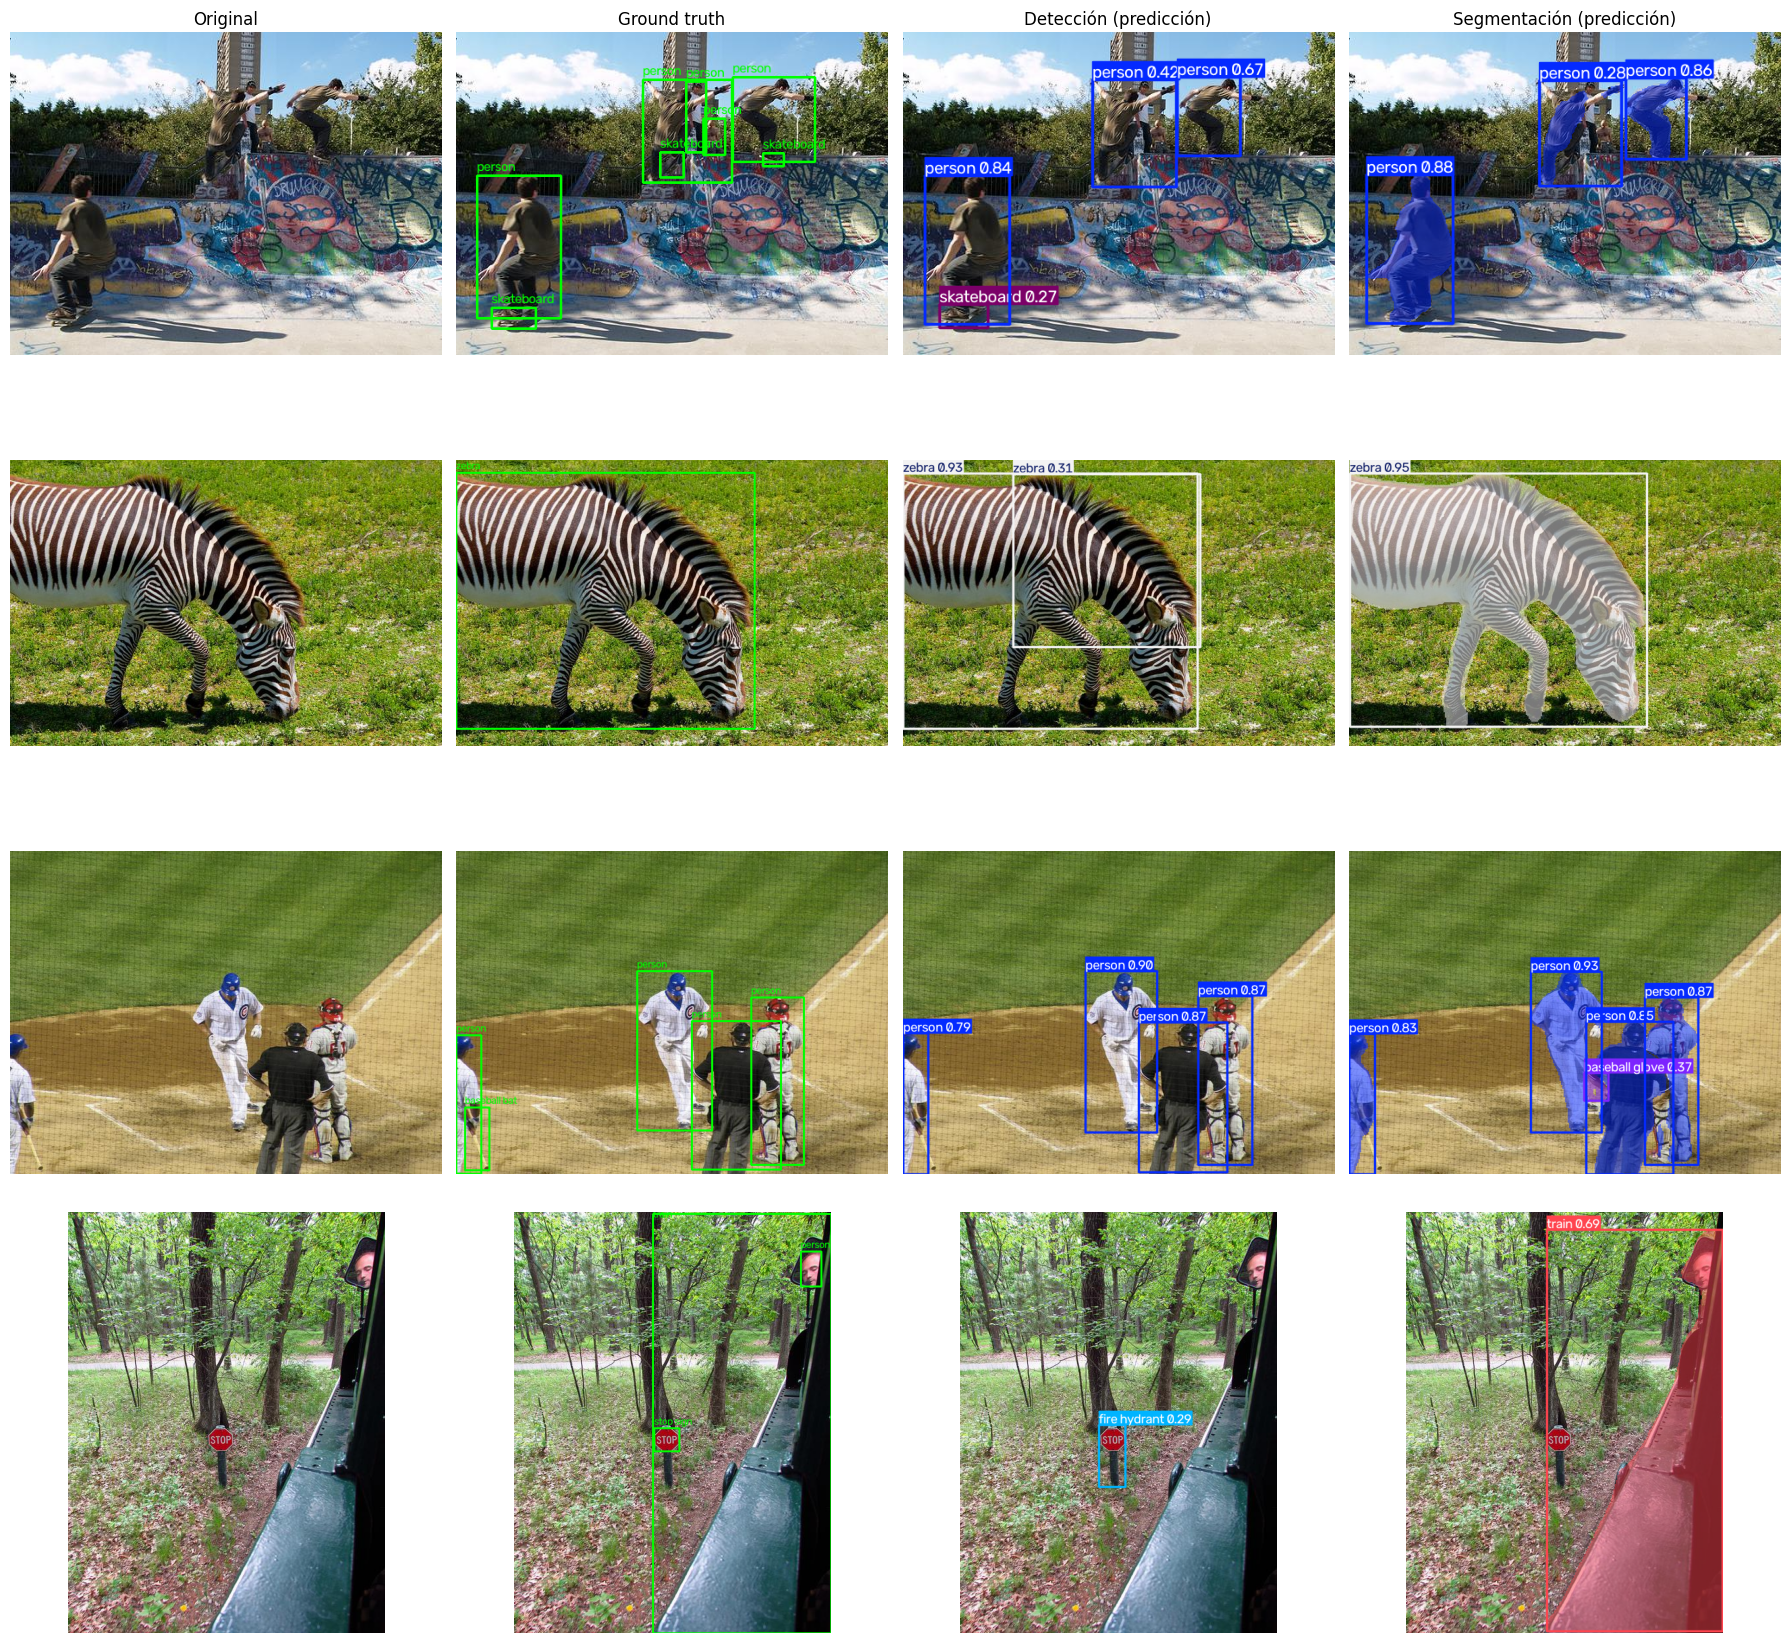

In [ ]:
def draw_gt_boxes(img, label_path, class_names):
    img = img.copy()
    h, w = img.shape[:2]
    if not label_path.exists():
        return img
    for line in open(label_path):
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, class_names[int(cls)], (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img


def draw_gt_masks(img, label_path, class_names):
    img = img.copy()
    h, w = img.shape[:2]
    if not label_path.exists():
        return img
    overlay = img.copy()
    for line in open(label_path):
        mask = polygon_label_to_mask(line, h, w)
        overlay[mask.astype(bool)] = (0, 0, 255)
    return cv2.addWeighted(overlay, 0.45, img, 0.55, 0)


N_EXAMPLES = 4
sample_images = random.Random(SEED).sample(test_images_seg, min(N_EXAMPLES, len(test_images_seg)))

fig, axes = plt.subplots(len(sample_images), 4, figsize=(18, 4.2 * len(sample_images)))
if len(sample_images) == 1:
    axes = axes.reshape(1, -1)

col_titles = ["Original", "Ground truth", "Detección (predicción)", "Segmentación (predicción)"]

for row, img_path in enumerate(sample_images):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    det_label_path = DET_SPLIT_DIR / "labels" / "test" / (img_path.stem + ".txt")
    seg_label_path = SEG_SPLIT_DIR / "labels" / "test" / (img_path.stem + ".txt")

    gt_boxes_img = cv2.cvtColor(draw_gt_boxes(img_bgr, det_label_path, det_names), cv2.COLOR_BGR2RGB)
    gt_masks_img = cv2.cvtColor(draw_gt_masks(img_bgr, seg_label_path, seg_names), cv2.COLOR_BGR2RGB)

    det_pred = model_det.predict(source=str(img_path), device=DEVICE, imgsz=IMG_SIZE, verbose=False)[0]
    det_pred_img = cv2.cvtColor(det_pred.plot(), cv2.COLOR_BGR2RGB)   # .plot() dibuja cajas + clase + confidence

    seg_pred = model_seg.predict(source=str(img_path), device=DEVICE, imgsz=IMG_SIZE, verbose=False)[0]
    seg_pred_img = cv2.cvtColor(seg_pred.plot(), cv2.COLOR_BGR2RGB)   # .plot() dibuja máscaras + clase + confidence

    for col, (title, im) in enumerate(zip(col_titles, [img_rgb, gt_boxes_img, det_pred_img, seg_pred_img])):
        axes[row, col].imshow(im)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig("resultados_visualizacion.png", dpi=120)
plt.show()


## 13. Conclusiones

### Resultados obtenidos

**Detección** (test set, transfer learning sobre `yolov8n.pt`):

| Métrica | Valor |
|---|---|
| Precision | 0.641 |
| Recall | 0.577 |
| F1-score | 0.608 |
| mAP@0.50 | 0.697 |
| mAP@0.50:0.95 | 0.527 |

**Segmentación** (test set, transfer learning sobre `yolov8n-seg.pt`):

| Métrica | Valor |
|---|---|
| Mask Precision | 0.885 |
| Mask Recall | 0.477 |
| Mask mAP@0.50 | 0.629 |
| Mask mAP@0.50:0.95 | 0.424 |
| IoU (promedio) | 0.731 |
| Dice (promedio) | 0.822 |

### Interpretación

- El modelo de **detección** alcanza un mAP@0.50 de 0.697, razonable para un modelo *nano* ajustado con solo ~90 imágenes de entrenamiento. La brecha entre mAP@0.50 (0.697) y mAP@0.50:0.95 (0.527) es normal: el segundo exige que la caja predicha coincida con mucha más precisión geométrica con la real (IoU hasta 0.95), y con tan pocos ejemplos por clase el modelo no siempre afina bien los bordes de la caja.

- El modelo de **segmentación** muestra un patrón muy marcado: **Mask Precision alta (0.885) pero Mask Recall baja (0.477)**. Esto significa que, cuando el modelo predice una máscara, casi siempre acierta en la clase y en la forma — pero deja bastantes objetos reales del ground truth sin detectar. Es coherente con el **IoU promedio (0.731) y el Dice promedio (0.822)** altos: en los objetos que sí detecta, la máscara se ajusta bastante bien al contorno real; el problema no es la calidad de la máscara sino la cantidad de instancias que logra capturar.

- **Ambos entrenamientos se detuvieron por *early stopping* (`patience=10`) mucho antes de llegar a las 25 épocas configuradas**, y en ambos casos el mejor modelo se ubicó prácticamente en la época 1:
  - *Detección*: 13/25 épocas completadas (~54 s en total). El `mAP@0.50:0.95` se mantiene casi plano entre las épocas 1-3 (0.535 → 0.537) y después empieza a oscilar hacia abajo, mientras que el `val/box_loss` sube de forma sostenida (0.641 en época 1 → 0.807 en época 13) — un indicio clásico de sobreajuste leve una vez pasadas las primeras épocas.
  - *Segmentación*: 11/25 épocas completadas (~1 min en total), con el mismo patrón: mejor resultado en época 1 y sin mejora en las 10 épocas siguientes.

  Esto tiene sentido dado el tamaño del dataset: con solo ~90 imágenes de entrenamiento, un modelo *ya preentrenado* en las 80 clases de COCO necesita muy poco *fine-tuning* para adaptarse, y seguir entrenando más allá de la primera época aporta poco o empieza a sobreajustar en vez de generalizar. Esto también explica el recall relativamente bajo en segmentación: el modelo se queda con los ajustes conservadores de las primeras épocas (alta precisión, pocas detecciones) en lugar de arriesgarse a detectar más instancias.

### Trabajo futuro

- **Aumentar el tamaño del subconjunto de imágenes** (por ejemplo, usar `coco8`→`coco128`→un subset propio de 500–1000 imágenes) para dar al modelo más señal antes de que el *early stopping* lo detenga — es probablemente el cambio con mayor impacto en el recall, ya que con más datos el modelo tendría margen real de mejora en varias épocas, no solo en la primera.
- **Relajar el `patience`** (p. ej. `patience=20` o desactivarlo con `patience=0`) para forzar más épocas y confirmar si de verdad no hay más mejora posible o si el *early stopping* está siendo demasiado agresivo para un dataset tan pequeño.
- Si se cuenta con más tiempo/hardware: subir `IMG_SIZE` a 640 (más detalle para objetos pequeños, que suelen ser los que más bajan el recall) o usar una variante más grande (`yolov8s`, `yolov8s-seg`) con GPU para usar CUDA.
- Dado que la precisión ya es alta en ambos modelos, el cuello de botella actual es recall, no calidad de las predicciones — cualquier mejora debería enfocarse en que el modelo detecte más instancias, no en afinar las que ya detecta.

---
